# Compress an orbital rotation into fewer Givens rotations

An [orbital rotation](../explanations/orbital-rotation.ipynb) on `norb` orbitals can be implemented as a network of Givens rotations arranged in a brickwork pattern of up to `norb` layers (see [`ffsim.linalg.givens_decomposition`](../api/stubs/ffsim.linalg.givens_decomposition.rst#ffsim.linalg.givens_decomposition)). On hardware, each layer costs circuit depth, so it is often worth trading a small amount of accuracy for a shallower circuit.

Passing `max_layers` (or `max_givens`) to `givens_decomposition` returns a *compressed* decomposition: it keeps the first few layers of the brickwork pattern and numerically optimizes their angles to best approximate the original orbital rotation. This guide measures how the approximation error decreases as more layers are kept, for two kinds of orbital rotation:

- one generated by time evolution under a **sparse** (nearest-neighbor hopping) Hamiltonian, and
- ones drawn from the **double factorization** of a molecular Hamiltonian.

## Setup

`givens_decomposition` returns the Givens rotations and diagonal phases of the decomposition, not the reconstructed matrix. The `reconstruct` helper below rebuilds the (approximate) orbital rotation from them, so we can compare it to the original.

We quantify the approximation error two ways, both as an infidelity (0 is exact, 1 is orthogonal):

- **Operator infidelity** $1 - |\mathrm{Tr}(U^\dagger V) / d|^2$ compares the original orbital rotation $U$ to the reconstruction $V$ directly, where $d$ is the number of orbitals.
- **State infidelity** $1 - |\langle \psi_U | \psi_V \rangle|^2$ compares the states obtained by applying $U$ and $V$ to a fixed reference state. This is the error that actually matters for a simulation.

Each example below sweeps `max_layers` from 0 (only the diagonal phases, no Givens rotations) up to `norb - 1` and records both infidelities.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
from scipy.linalg.lapack import zrot

import ffsim


def reconstruct(givens_rotations, phase_shifts):
    """Reconstruct a unitary matrix from its Givens decomposition."""
    mat = np.diag(phase_shifts.astype(complex))
    for c, s, i, j in givens_rotations[::-1]:
        mat[:, j], mat[:, i] = zrot(mat[:, j], mat[:, i], c, s.conjugate())
    return mat

## Time evolution of a sparse Hamiltonian

The first example is the orbital rotation $e^{-i \Delta t\, h}$ generated by time evolution under a nearest-neighbor hopping Hamiltonian $h$. For short times the rotation is close to the identity and mixes only neighboring orbitals, so a few brickwork layers capture it well. As $\Delta t$ grows, the rotation becomes more delocalized and more layers are needed to reach the same accuracy.

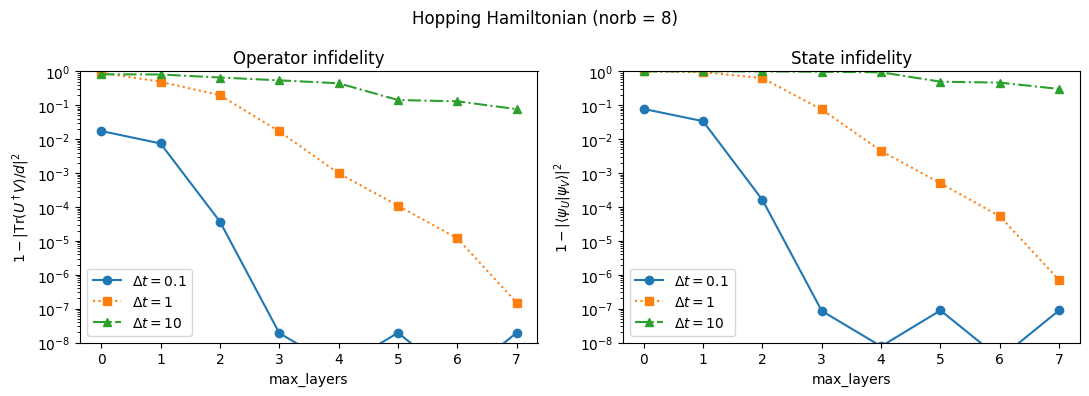

In [2]:
norb = 8
nelec = (norb // 2, norb // 2)
h1e = -np.diag(np.ones(norb - 1), k=1) - np.diag(np.ones(norb - 1), k=-1)

time_steps = [1e-1, 1, 10]
orbital_rotations = [
    scipy.linalg.expm(-1j * time_step * h1e) for time_step in time_steps
]
vec = ffsim.random.random_state_vector(ffsim.dim(norb, nelec), seed=12345)

op_infidelities = np.zeros((len(orbital_rotations), norb))
state_infidelities = np.zeros((len(orbital_rotations), norb))
for row, orbital_rotation in enumerate(orbital_rotations):
    exact_vec = ffsim.apply_orbital_rotation(
        vec, orbital_rotation, norb=norb, nelec=nelec
    )
    for max_layers in range(norb):
        givens_rotations, phase_shifts = ffsim.linalg.givens_decomposition(
            orbital_rotation, max_layers=max_layers
        )
        compressed_rotation = reconstruct(givens_rotations, phase_shifts)
        compressed_vec = ffsim.apply_orbital_rotation(
            vec, compressed_rotation, norb=norb, nelec=nelec
        )
        op_overlap = np.trace(orbital_rotation.conj().T @ compressed_rotation) / norb
        op_infidelities[row, max_layers] = 1 - abs(op_overlap) ** 2
        state_overlap = np.vdot(exact_vec, compressed_vec)
        state_infidelities[row, max_layers] = 1 - abs(state_overlap) ** 2

markers = ["o", "s", "^"]
linestyles = ["-", ":", "-."]
fig, (ax_op, ax_state) = plt.subplots(1, 2, figsize=(11, 4))
for time_step, op_row, state_row, marker, linestyle in zip(
    time_steps, op_infidelities, state_infidelities, markers, linestyles
):
    label = rf"$\Delta t = {time_step}$"
    ax_op.plot(range(norb), op_row, marker=marker, linestyle=linestyle, label=label)
    ax_state.plot(
        range(norb), state_row, marker=marker, linestyle=linestyle, label=label
    )

for ax in (ax_op, ax_state):
    ax.set_yscale("log")
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("max_layers")
    ax.legend()
ax_op.set_ylabel(r"$1 - |\mathrm{Tr}(U^\dagger V) / d|^2$")
ax_op.set_title("Operator infidelity")
ax_state.set_ylabel(r"$1 - |\langle \psi_U | \psi_V \rangle|^2$")
ax_state.set_title("State infidelity")

fig.suptitle(f"Hopping Hamiltonian (norb = {norb})")
fig.tight_layout()

## Orbital rotations from a double factorization

The second example uses the orbital rotations that appear in the [double factorization](../explanations/double-factorized.ipynb) of a molecular Hamiltonian, here obtained from the [`UCJOpSpinBalanced`](../api/stubs/ffsim.UCJOpSpinBalanced.rst#ffsim.UCJOpSpinBalanced) ansatz for N$_2$. Unlike the hopping example, these rotations are dense and generic, so compression buys much less: the infidelity stays near 1 until nearly the full brickwork pattern is kept.

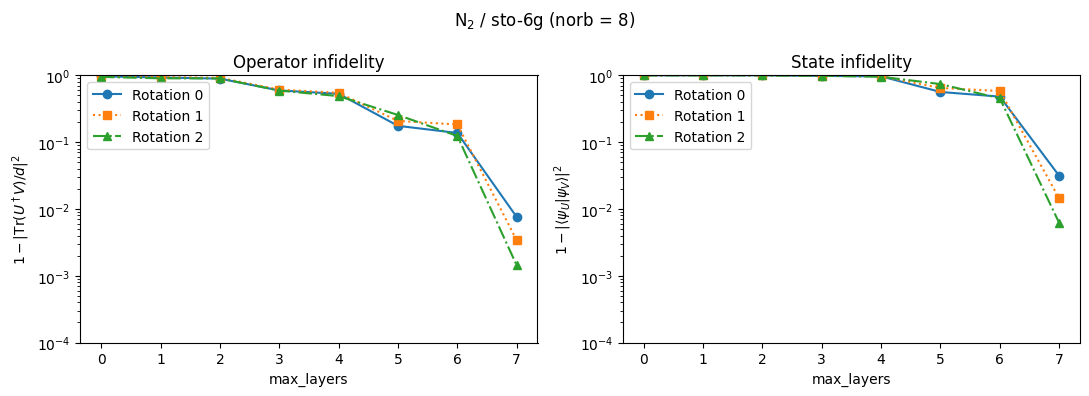

In [3]:
import pyscf.cc
import pyscf.gto
import pyscf.scf

bond_distance = 1.2
basis = "sto-6g"
mol = pyscf.gto.Mole()
mol.build(
    atom=[("N", (-0.5 * bond_distance, 0, 0)), ("N", (0.5 * bond_distance, 0, 0))],
    basis=basis,
    symmetry="Dooh",
    verbose=0,
)
scf = pyscf.scf.RHF(mol)
scf.kernel()

active_space = list(range(2, mol.nao_nr()))
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
nelec = (n_electrons // 2, n_electrons // 2)
ccsd = pyscf.cc.RCCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
)
ccsd.kernel()

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=ccsd.t2, n_reps=3, optimize=True)
orbital_rotations = ucj_op.orbital_rotations
vec = ffsim.random.random_state_vector(ffsim.dim(norb, nelec), seed=12345)

op_infidelities = np.zeros((len(orbital_rotations), norb))
state_infidelities = np.zeros((len(orbital_rotations), norb))
for row, orbital_rotation in enumerate(orbital_rotations):
    exact_vec = ffsim.apply_orbital_rotation(
        vec, orbital_rotation, norb=norb, nelec=nelec
    )
    for max_layers in range(norb):
        givens_rotations, phase_shifts = ffsim.linalg.givens_decomposition(
            orbital_rotation, max_layers=max_layers
        )
        compressed_rotation = reconstruct(givens_rotations, phase_shifts)
        compressed_vec = ffsim.apply_orbital_rotation(
            vec, compressed_rotation, norb=norb, nelec=nelec
        )
        op_overlap = np.trace(orbital_rotation.conj().T @ compressed_rotation) / norb
        op_infidelities[row, max_layers] = 1 - abs(op_overlap) ** 2
        state_overlap = np.vdot(exact_vec, compressed_vec)
        state_infidelities[row, max_layers] = 1 - abs(state_overlap) ** 2

markers = ["o", "s", "^"]
linestyles = ["-", ":", "-."]
fig, (ax_op, ax_state) = plt.subplots(1, 2, figsize=(11, 4))
for i, (op_row, state_row, marker, linestyle) in enumerate(
    zip(op_infidelities, state_infidelities, markers, linestyles)
):
    label = f"Rotation {i}"
    ax_op.plot(range(norb), op_row, marker=marker, linestyle=linestyle, label=label)
    ax_state.plot(
        range(norb), state_row, marker=marker, linestyle=linestyle, label=label
    )

for ax in (ax_op, ax_state):
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1)
    ax.set_xlabel("max_layers")
    ax.legend()
ax_op.set_ylabel(r"$1 - |\mathrm{Tr}(U^\dagger V) / d|^2$")
ax_op.set_title("Operator infidelity")
ax_state.set_ylabel(r"$1 - |\langle \psi_U | \psi_V \rangle|^2$")
ax_state.set_title("State infidelity")

fig.suptitle(f"N$_2$ / {basis} (norb = {norb})")
fig.tight_layout()